# V4-4-0 Portfolio

อัปเดตจาก `V3-4_portfolio` ให้ตรงกับ pipeline ใหม่ (`v4-3-0_inferencing`):
- **Data source**: รับ arrays จาก inferencing loop โดยตรง (`all_prices_gen`, `all_prices_real`, `all_log_ret_gen`, `all_log_ret_real`, `all_dates`) แทน `SimulationDataset` / `.npz`
- **Tensor dims**: shape ใหม่ `(N, W, A, C)` แทน `(N, A, W, D, C)` — A และ W สลับกัน, ไม่มี D
- **No GBM**: ไม่มี `simulate_mc_gbm` เป็น benchmark อีกแล้ว — มีแค่ `"model"` strategy เดียว
- **Imports**: ใช้ `load_data` / `build_datasets` (utils/io.py) แทน `load_variant`

# 1. Import & Config

In [83]:
import sys, os, json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import quantstats as qs
from pathlib import Path

from config import InferenceConfig, DDPMTransformerConfig, FMConfig
from utils import setup_logging, setup_random_seed, load_data, build_datasets
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR
from entities import Portfolio

logger = setup_logging()
logger.info("✓ Imports OK")

2026-07-25 19:19:31,978 - utils.setup - INFO - Logger is set up.
2026-07-25 19:19:31,979 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config

In [84]:
# 1. Import & Config
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import InferenceConfig
from utils import setup_logging, setup_random_seed

logger = setup_logging()
logger.info("✓ Imports OK")

# ── 1.1 Config ────────────────────────────────────────────────────────
cfg = InferenceConfig(
    name             = "portfolio_config",
    # group            = "set_index",
    # subgroup         = "set_idx50",
    # experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    # num_simulations  = 1000,

    group            = "sp_index",
    subgroup         = "sp_idx100",
    experiment_name  = "v1_trial01_w20a88_ddpm_warmup-cosine_optuna",
    num_simulations  = 100,

    checkpoint_file  = "best_model.pt",
    random_seed      = 72,
)
cfg = cfg.apply_experiment_config()

SPLIT = "test" # เปลี่ยนเป็น 'test' ได้ตามที่เซฟมา
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"

setup_random_seed(cfg.random_seed)

print("=" * 60)
print("  V4-4-0 PORTFOLIO")
print("=" * 60)
print(f"  Experiment      : {cfg.experiment_name}")
print(f"  Simulation dir  : {sim_dir}")
print("=" * 60)

2026-07-25 19:19:32,228 - utils.setup - INFO - Logger is set up.
2026-07-25 19:19:32,229 - utils.setup - INFO - ✓ Imports OK
[InferenceConfig] model_params loaded from best_params.json
  V4-4-0 PORTFOLIO
  Experiment      : v1_trial01_w20a88_ddpm_warmup-cosine_optuna
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/test_all_n100


# 3. Portfolio Optimization Loop

In [85]:
# 2. Load Simulation Data (Direct Array Load)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"Not found: {npz_path} (รัน inferencing หรือยัง?)")

data = np.load(npz_path, allow_pickle=True)

# โหลด arrays (T = จำนวน window, N = sims, W = window_size, A = assets, C = channels)
all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  all_prices_gen   : {all_prices_gen.shape}")
print(f"  all_prices_real  : {all_prices_real.shape}")
print(f"  all_log_ret_gen  : {all_log_ret_gen.shape}")
print(f"  all_log_ret_real : {all_log_ret_real.shape}")
print(f"  all_dates        : {all_dates.shape}")
print(f"  tickers          : {len(tickers)} assets")

  ✓ Loaded 1 file from test_all_n100
  all_prices_gen   : (50, 100, 20, 88)
  all_prices_real  : (50, 20, 88)
  all_log_ret_gen  : (50, 100, 20, 88, 4)
  all_log_ret_real : (50, 20, 88, 4)
  all_dates        : (50,)
  tickers          : 88 assets


In [86]:
# 2.2 Prepare GT & MC Returns/Prices
# แปลง (T, N, W, A) -> (N, T*W, A) สำหรับ MC
# แปลง (T, W, A) -> (T*W, A) สำหรับ GT

CLOSE_IDX = 0  # เปลี่ยนให้ตรงกับ features_lr ของคุณ (0 = Close ปกติใน v4)

# ── 1. Ground Truth (GT) ──────────────────────────────────────────────
# log_ret_real : (T, W, A, C) -> เอาแค่ channel Close
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # (T*W, A)

# prices_real : (T, W, A) ไม่มี C แล้ว
gt_prices = all_prices_real.reshape(-1, A)    # (T*W, A)

# dates : (T, W) -> flatten เป็น 1D (T*W)
if all_dates.ndim == 2:
    gt_dates = all_dates.flatten()
else:
    gt_dates = all_dates

# ── 2. Monte Carlo (MC) ───────────────────────────────────────────────
# log_ret_gen : (T, N, W, A, C) -> เอาแค่ channel Close
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N มาข้างหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # ยุบรวมแกนเวลา -> (N, T*W, A)

# prices_gen : (T, N, W, A)
mc_prices = all_prices_gen.transpose(1, 0, 2, 3) # (N, T, W, A)
mc_prices = mc_prices.reshape(N, -1, A)          # (N, T*W, A)

print("── Shapes after preparation ───────────────────────")
print(f"  gt_returns  : {gt_returns.shape}   (n_periods, n_assets)")
print(f"  gt_prices   : {gt_prices.shape}   (n_periods, n_assets)")
print(f"  gt_dates    : {gt_dates.shape}")
print(f"  mc_returns  : {mc_returns.shape}  (n_sims, n_periods, n_assets)")
print(f"  mc_prices   : {mc_prices.shape}   (n_sims, n_periods, n_assets)")
print("───────────────────────────────────────────────────")

── Shapes after preparation ───────────────────────
  gt_returns  : (1000, 88)   (n_periods, n_assets)
  gt_prices   : (1000, 88)   (n_periods, n_assets)
  gt_dates    : (50,)
  mc_returns  : (100, 1000, 88)  (n_sims, n_periods, n_assets)
  mc_prices   : (100, 1000, 88)   (n_sims, n_periods, n_assets)
───────────────────────────────────────────────────


In [87]:
CLOSE_IDX = 0  # channel สำหรับราคา Close

# 1. Ground Truth (GT): จับ T windows มาเรียงต่อกันให้เป็น n_periods ยาวๆ (T*W)
gt_returns = all_log_ret_real[..., CLOSE_IDX] # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)        # กลายเป็น (T*W, A) แบบเส้นเดียว

gt_prices = all_prices_real.reshape(-1, A)    # กลายเป็น (T*W, A) แบบเส้นเดียว

# จัดการ Date Index: เนื่องจากไม่มีการ Overlap เราสามารถสร้างตารางเวลาเรียงต่อกันได้เลย
all_dates_flat = []
for i in range(T):
    # รองรับเผื่อเป็น scalar 1D หรือ 2D
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 2. Monte Carlo (MC): ยุบรวมแกน T กับ W เข้าด้วยกัน
mc_returns = all_log_ret_gen[..., CLOSE_IDX]  # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3) # ดึง N ออกมาหน้าสุด (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)     # กลายเป็น (N, T*W, A) แบบเส้นเดียว

print("── Target Shapes for Portfolio ────────────────────")
print(f"  gt_returns : {gt_returns.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  gt_prices  : {gt_prices.shape}   (n_periods = {T*W}, n_assets = {A})")
print(f"  datetime   : {len(datetime_index)} days")
print(f"  mc_returns : {mc_returns.shape}  (n_paths = {N}, n_periods = {T*W}, n_assets = {A})")
print("───────────────────────────────────────────────────")

── Target Shapes for Portfolio ────────────────────
  gt_returns : (1000, 88)   (n_periods = 1000, n_assets = 88)
  gt_prices  : (1000, 88)   (n_periods = 1000, n_assets = 88)
  datetime   : 1000 days
  mc_returns : (100, 1000, 88)  (n_paths = 100, n_periods = 1000, n_assets = 88)
───────────────────────────────────────────────────


In [88]:
CLOSE_FEATURE    = "Close"      # ชื่อ channel ที่ใช้ reconstruct ราคา

loaded   = load_data(str(cfg.processed_dir))
datasets = build_datasets(loaded)

tickers       = loaded["tickers"]
features_lr   = loaded["features_lr"]
features_cond = loaded["features_cond"]
scalers_x     = loaded["scalers_x"]
scalers_cond  = loaded["scalers_cond"]

CLOSE_IDX = features_lr.index(CLOSE_FEATURE)

print(f"tickers      : {tickers}")
print(f"features_lr  : {features_lr}")
print(f"close idx    : {CLOSE_IDX}")
for s in ("train", "val", "test"):
    print(f"  {s:<6} n_windows={len(datasets[s])}")

tickers      : ['AAPL', 'ABT', 'ACN', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMZN', 'AXP', 'BA', 'BAC', 'BIIB', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CHTR', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GOOG', 'GOOGL', 'GS', 'HAL', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KMB', 'KO', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MDT', 'MET', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'OXY', 'PEP', 'PFE', 'PG', 'PM', 'QCOM', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
features_lr  : ['Close', 'High', 'Low', 'Open']
close idx    : 0
  train  n_windows=2004
  val    n_windows=246
  test   n_windows=996


In [89]:
import random
SIM_MODE = "strided"    # ← เปลี่ยนตรงนี้: "single" | "full" | "strided"

# ── config เฉพาะของแต่ละ mode ─────────────────────────────────
SINGLE_WINDOW_IDX  = None   # None → สุ่ม, หรือใส่ int ตรง ๆ เช่น 42
STRIDED_WINDOW_W   = W      # stride = W (non-overlapping), หรือตัวเลขอื่น

# ── validate ──────────────────────────────────────────────────
assert SIM_MODE in ("single", "full", "strided"), \
    f"SIM_MODE ต้องเป็น 'single' | 'full' | 'strided', ได้: {SIM_MODE!r}"

ds        = datasets[SPLIT]
n_windows = len(ds)
dates     = loaded["splits"][SPLIT]["dates"]

if SIM_MODE == "single":
    if SINGLE_WINDOW_IDX is None:
        _w = random.randint(0, n_windows - 1)
    else:
        assert 0 <= SINGLE_WINDOW_IDX < n_windows, \
            f"SINGLE_WINDOW_IDX={SINGLE_WINDOW_IDX} out of range [0, {n_windows-1}]"
        _w = SINGLE_WINDOW_IDX
    window_idxs = [_w]
    print(f"  MODE : single window")
    print(f"  idx  : {_w}  (date={dates[_w]})")

elif SIM_MODE == "full":
    window_idxs = list(range(n_windows))
    print(f"  MODE : full split ({SPLIT})")
    print(f"  windows : {n_windows}")

elif SIM_MODE == "strided":
    stride      = max(1, STRIDED_WINDOW_W)
    window_idxs = list(range(0, n_windows, stride))
    print(f"  MODE : strided (stride={stride}, W={W})")
    print(f"  windows total   : {n_windows}")
    print(f"  windows to run  : {len(window_idxs)}")

print(f"  split           : {SPLIT}")
print(f"  num_simulations : {cfg.num_simulations}")

  MODE : strided (stride=20, W=20)
  windows total   : 996
  windows to run  : 50
  split           : test
  num_simulations : 100


In [90]:
import torch
from utils import simulate_mc_gbm

print("🎲 Simulating GBM Benchmark...")

# แปลง gt_returns ที่แบนแล้ว (T*W, A) เป็น Tensor
gt_returns_tensor = torch.tensor(gt_returns, dtype=torch.float32)

# จำนวน Paths (ดึงจากขนาดของ mc_returns)
n_paths = mc_returns.shape[0]
# ความยาววันทั้งหมด
horizon_len = len(gt_returns)

# สร้าง GBM โดยใช้ mu, sigma จาก gt_returns_tensor
gbm_tensor = simulate_mc_gbm(
    log_returns=gt_returns_tensor,
    n_paths=n_paths,
    horizon=horizon_len
)

# แปลงกลับเป็น NumPy (ได้รูปทรง: [n_paths, horizon_len, n_assets])
gbm_returns = gbm_tensor.cpu().numpy()
print(f"  gbm_returns: {gbm_returns.shape}")
print("──────────────────────────────────────────────────────────────────")

🎲 Simulating GBM Benchmark...
  gbm_returns: (100, 1000, 88)
──────────────────────────────────────────────────────────────────


In [91]:
# 2. Load Simulation Data (จาก Inferencing)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"ไม่พบไฟล์ {npz_path} กรุณารัน V4-3-0 Inferencing ก่อน")

data = np.load(npz_path, allow_pickle=True)

all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  Total Windows (T) = {T}, Simulations (N) = {N}, Window Size (W) = {W}")

  ✓ Loaded 1 file from test_all_n100
  Total Windows (T) = 50, Simulations (N) = 100, Window Size (W) = 20


In [92]:
# 3. Prepare All-Window Concatenated Data
CLOSE_IDX = 0

# 3.1 Ground Truth (GT): จับ T windows มาต่อกันเป็นเส้นเดียวยาวๆ
gt_returns = all_log_ret_real[..., CLOSE_IDX]   # (T, W, A)
gt_returns = gt_returns.reshape(-1, A)          # (T*W, A)
gt_prices = all_prices_real.reshape(-1, A)      # (T*W, A)

# 3.2 จัดการ Datetime Index
all_dates_flat = []
for i in range(T):
    date_val = all_dates[i] if np.isscalar(all_dates[i]) else all_dates[i, -1]
    dates_w = pd.bdate_range(end=pd.Timestamp(date_val), periods=W)
    all_dates_flat.append(dates_w)

datetime_index = pd.DatetimeIndex(np.concatenate(all_dates_flat))

# 3.3 Monte Carlo (MC): ดึง N ออกมาหน้าสุด แล้วยุบเวลา (T*W)
mc_returns = all_log_ret_gen[..., CLOSE_IDX]     # (T, N, W, A)
mc_returns = mc_returns.transpose(1, 0, 2, 3)    # (N, T, W, A)
mc_returns = mc_returns.reshape(N, -1, A)        # (N, T*W, A)

print(f"  ✓ gt_returns shape : {gt_returns.shape}")
print(f"  ✓ mc_returns shape : {mc_returns.shape}")
print(f"  ✓ Date Range       : {datetime_index[0].date()} to {datetime_index[-1].date()}")

  ✓ gt_returns shape : (1000, 88)
  ✓ mc_returns shape : (100, 1000, 88)
  ✓ Date Range       : 2021-12-15 to 2025-12-08


In [93]:
all_dates.shape

(50,)

📁 Created/Ready to use Folder: Report_SP100_Opt20_Rebalance5_SolverSCS
🚀 เริ่มทำ Optimization | OPT_WINDOW = 20 วัน | Rebalance ทุก 5 วัน...
  ✓ Optimization เสร็จสิ้น
📈 กำลังจำลองพอร์ตโฟลิโอด้วย VectorBT...

📊 สรุปการเลือกใช้ Objective (รวมทั้งหมด 50 ครั้ง):
   - Max Sharpe: 46 ครั้ง
   - Minimum Variance: 4 ครั้ง
📸 บันทึกสำเร็จ: Report_SP100_Opt20_Rebalance5_SolverSCS/Objective_PieChart_SP100_Opt20_Rebalance5_SolverSCS.png


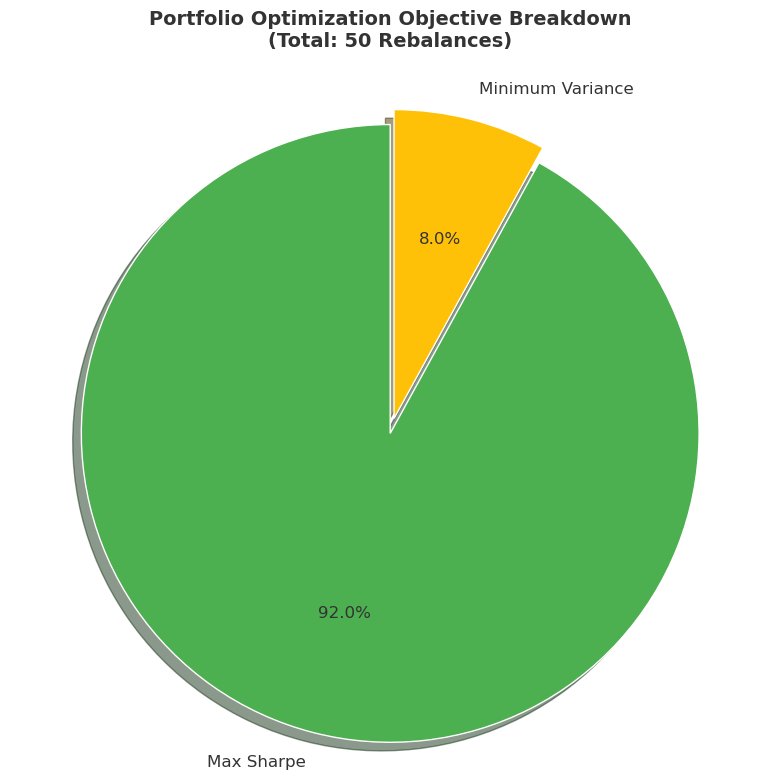

In [ ]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier
import vectorbt as vbt
import quantstats as qs
import matplotlib.pyplot as plt  # <--- เพิ่มไลบรารีสำหรับวาดกราฟ Pie Chart
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. ตั้งค่า Parameter
# ==========================================
OPT_WINDOW = 20      # จำนวนวันย้อนหลังที่ใช้คำนวณ μ, Σ (ต้อง <= W)
REBALANCE_FREQ = 5   # ความถี่ Rebalance (ทุกๆ กี่วัน)
RF_RATE = 0.02
TRADING_FEE = 0.0025
TRADING_DAYS = 252
SOLVER = "SCS"  # หรือ "ECOS", "OSQP", "MOSEK" (ถ้ามี license)

ASSET_NAME = "SP100"  # สามารถเปลี่ยนเป็นชื่อกลุ่มหุ้นของคุณได้ เช่น "SET50", "TechStocks"
# ASSET_NAME = "SET50"  # สามารถเปลี่ยนเป็นชื่อกลุ่มหุ้นของคุณได้ เช่น "SET50", "TechStocks"
SOLVER_NAME = SOLVER      # ใส่ชื่อ Solver ที่คุณใช้งาน

folder_name = f"Report_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}"

weights_filename = f"Weights_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"
equity_filename = f"Portfolio-Equity_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"
reports_filename = f"All_Reports_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.csv"

# ==========================================
# 3. สร้าง Folder (ถ้ายังไม่มี)
# ==========================================
# ใช้ Pathlib เพื่อความสะดวกในการจัดการ Path
save_dir = Path(folder_name)
save_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Created/Ready to use Folder: {save_dir}")

# 🔥 เช็ค Logic: OPT_WINDOW ต้องไม่เกิน W
if OPT_WINDOW > W:
    raise ValueError(f"🚨 ข้อผิดพลาด: OPT_WINDOW ({OPT_WINDOW}) ใหญ่กว่าขนาด Window W ({W})")

# ==========================================
# 1. การเตรียมข้อมูล & วันที่ Rebalance
# ==========================================
close_log_ret_gen = all_log_ret_gen[:, :, :, :, 0]

df_prices_full = pd.DataFrame(gt_prices, index=datetime_index, columns=tickers)
df_prices_full = df_prices_full[~df_prices_full.index.duplicated(keep='last')]

# 🔥 แก้ไขเรียบร้อย: เริ่ม Rebalance วันแรกที่สะสมข้อมูลครบ OPT_WINDOW (index = OPT_WINDOW - 1)
rebalance_dates = df_prices_full.index[OPT_WINDOW - 1 :: REBALANCE_FREQ]

if len(rebalance_dates) > T:
    rebalance_dates = rebalance_dates[:T]

weights_list = []
print(f"🚀 เริ่มทำ Optimization | OPT_WINDOW = {OPT_WINDOW} วัน | Rebalance ทุก {REBALANCE_FREQ} วัน...")

# ==========================================
# 2. คำนวณ μ และ Σ
# ==========================================
# 📊 เพิ่มตัวแปรสำหรับเก็บสถิติรูปแบบการ Optimize
count_max_sharpe = 0
count_min_volatility = 0

for t in range(T):
    mu_paths = []
    cov_paths = []

    for n in range(N):
        # ดึงข้อมูลเฉพาะช่วง OPT_WINDOW วันสุดท้ายของ Window นั้นๆ
        path_log_returns = close_log_ret_gen[t, n, -OPT_WINDOW:, :]
        path_simple_returns = np.exp(path_log_returns) - 1

        mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
        cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

        mu_paths.append(mu_m)
        cov_paths.append(cov_m)

    # Statistical Aggregation
    mu_ensemble = np.mean(mu_paths, axis=0)
    cov_ensemble = np.mean(cov_paths, axis=0)

    mu_series = pd.Series(mu_ensemble, index=tickers)
    cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

    epsilon = 1e-4
    cov_df = cov_df + (np.eye(len(cov_df)) * epsilon)

    # Modern Portfolio Theory (MPT) Optimizer
    ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1), solver=SOLVER)

    try:
        raw_weights = ef.max_sharpe(risk_free_rate=RF_RATE)
        count_max_sharpe += 1  # <--- เก็บสถิติเมื่อใช้ Max Sharpe สำเร็จ

    except ValueError:
        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))
        raw_weights = ef.min_volatility()
        count_min_volatility += 1  # <--- เก็บสถิติเมื่อเข้าเงื่อนไข Fallback (Min Volatility)

    cleaned_weights = ef.clean_weights()
    w_array = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_list.append(w_array)

df_weights = pd.DataFrame(weights_list, index=rebalance_dates, columns=tickers)
df_weights_full = df_weights.reindex(df_prices_full.index)
print("  ✓ Optimization เสร็จสิ้น")

print("📈 กำลังจำลองพอร์ตโฟลิโอด้วย VectorBT...")

# 🔥 ขยายตารางน้ำหนักให้มีจำนวนวัน (820 วัน) เท่ากับราคา (วันไหนไม่ rebalance จะเป็น NaN)
df_weights_full = df_weights.reindex(df_prices_full.index)

# 4.1 พอร์ตหลัก (Generative AI + MPT)
portfolio = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_full,       # <--- เปลี่ยนมาใช้ df_weights_full ตรงนี้
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

# 4.2 พอร์ตเปรียบเทียบแบบ Equal Weight (Benchmark)
# สร้างน้ำหนักเท่ากันทุกตัวเฉพาะวัน Rebalance แล้วขยายให้เต็ม 820 วันเหมือนกัน
df_weights_ew = pd.DataFrame(1.0 / len(tickers), index=rebalance_dates, columns=tickers)
df_weights_ew_full = df_weights_ew.reindex(df_prices_full.index)

portfolio_ew = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_ew_full,    # <--- ใช้แบบ _full เช่นกัน
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

# ==========================================
# 2.5 แสดงผลสัดส่วนการใช้ Objective (Pie Chart)
# ==========================================
total_opts = count_max_sharpe + count_min_volatility
print(f"\n📊 สรุปการเลือกใช้ Objective (รวมทั้งหมด {total_opts} ครั้ง):")
print(f"   - Max Sharpe: {count_max_sharpe} ครั้ง")
print(f"   - Minimum Variance: {count_min_volatility} ครั้ง")

# วาดกราฟ Pie Chart
labels = ['Max Sharpe', 'Minimum Variance']
sizes = [count_max_sharpe, count_min_volatility]
colors = ['#4CAF50', '#FFC107']
explode = (0.05, 0)  # ดึงชิ้นส่วน Max Sharpe ออกมาเล็กน้อยให้ดูมีมิติ

# เพิ่มขนาด Figure เล็กน้อยเพื่อให้มีพื้นที่หายใจ
plt.figure(figsize=(8, 8))

# ปรับ startangle เป็น 90 เพื่อหมุนให้ป้ายกำกับไม่ไปชนขอบบนสุด
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})

# เพิ่ม pad=30 เพื่อดัน Title ขึ้นไปให้ห่างจากตัวกราฟ
plt.title(f'Portfolio Optimization Objective Breakdown\n(Total: {total_opts} Rebalances)',
          fontsize=14, weight='bold', pad=30)

plt.axis('equal')  # ทำให้พายชาร์ตเป็นวงกลมสมบูรณ์

# ใช้ tight_layout เพื่อจัดระเบียบขอบกราฟไม่ให้ข้อความถูกตัดทิ้ง
plt.tight_layout()

# 🔥 กำหนดชื่อไฟล์และบันทึกรูปลง Directory ที่เตรียมไว้
pie_filename = f"Objective_PieChart_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"
pie_path = save_dir / pie_filename
plt.savefig(pie_path, bbox_inches='tight', dpi=300)
print(f"📸 บันทึกสำเร็จ: {pie_path}")

plt.show()

In [95]:
rebalance_dates.shape

(50,)

In [96]:
# สร้าง Weights แบบ 1/N
ew_weight_val = 1.0 / len(tickers)
df_weights_ew = pd.DataFrame(ew_weight_val, index=rebalance_dates, columns=tickers)

# Reindex ให้ตรงกับ daily prices (820 วัน)
df_weights_ew_full = df_weights_ew.reindex(df_prices_full.index)

# VectorBT
portfolio_ew = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_ew_full,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

print("✅ EW Baseline พร้อมใช้งาน")

✅ EW Baseline พร้อมใช้งาน


In [97]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

gbm_weights_list = []

print("🚀 เริ่มรัน Baseline: GBM + MPT Optimization...")

for idx, reb_date in enumerate(rebalance_dates):
    # 1. หาตำแหน่ง Index ของวัน Rebalance ใน df_prices_full
    loc = df_prices_full.index.get_loc(reb_date)

    # 2. ดึงข้อมูลย้อนหลัง OPT_WINDOW วันก่อนหน้าวัน Rebalance
    hist_prices = df_prices_full.iloc[loc - OPT_WINDOW + 1 : loc + 1]

    # คำนวณ Log Returns จากข้อมูลจริงย้อนหลัง
    hist_log_returns = np.log(hist_prices / hist_prices.shift(1)).dropna()

    # 3. ประมาณค่า Parameter จากประวัติศาสตร์ (Mean & Covariance)
    dt = 1 / TRADING_DAYS
    mu_daily = hist_log_returns.mean().values
    cov_daily = hist_log_returns.cov().values

    # 4. Monte Carlo Simulation ด้วย GBM ให้ได้ N Paths, W Days (ขนานกับ GenAI)
    num_assets = len(tickers)
    simulated_paths_log_ret = []

    # Cholesky decomposition สำหรับสร้าง correlated normal random variables
    try:
        L = np.linalg.cholesky(cov_daily)
    except np.linalg.LinAlgError:
        # กันกรณี Covariance matrix ไม่เป็น Positive Definite
        cov_daily += np.eye(num_assets) * 1e-6
        L = np.linalg.cholesky(cov_daily)

    drift = mu_daily

    for n in range(N):
        # สุ่ม Z ~ N(0, 1) ขนาด (W, num_assets)
        Z = np.random.normal(size=(W, num_assets))
        path_ret = drift + Z @ L.T
        simulated_paths_log_ret.append(path_ret)

    # simulated_paths_log_ret shape: (N, W, num_assets)
    simulated_paths_log_ret = np.array(simulated_paths_log_ret)

    # 5. คำนวณ μ และ Σ รวมจาก N Paths (Ensemble Aggregation)
    mu_paths = []
    cov_paths = []

    for n in range(N):
        path_simple_returns = np.exp(simulated_paths_log_ret[n, -OPT_WINDOW:, :]) - 1
        mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
        cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS

        mu_paths.append(mu_m)
        cov_paths.append(cov_m)

    mu_ensemble = np.mean(mu_paths, axis=0)
    cov_ensemble = np.mean(cov_paths, axis=0)

    mu_series = pd.Series(mu_ensemble, index=tickers)
    cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)

    # 6. MPT Optimization
    ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1), solver=SOLVER)

    try:
        raw_weights = ef.max_sharpe(risk_free_rate=RF_RATE)
    except ValueError:
        raw_weights = ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    w_array = np.array([cleaned_weights[ticker] for ticker in tickers])
    gbm_weights_list.append(w_array)

# สร้าง DataFrame ของ Weights และ Reindex ให้แมตช์เต็ม 820 วัน
df_weights_gbm = pd.DataFrame(gbm_weights_list, index=rebalance_dates, columns=tickers)
df_weights_gbm_full = df_weights_gbm.reindex(df_prices_full.index)

# VectorBT สำหรับ GBM + MPT
portfolio_gbm = vbt.Portfolio.from_orders(
    close=df_prices_full,
    size=df_weights_gbm_full,
    size_type='targetpercent',
    cash_sharing=True,
    call_seq='auto',
    fees=TRADING_FEE,
    freq='1D'
)

print("✅ GBM + MPT Baseline พร้อมใช้งาน")

🚀 เริ่มรัน Baseline: GBM + MPT Optimization...
✅ GBM + MPT Baseline พร้อมใช้งาน


In [98]:
# import quantstats as qs

# # ดึง Return Series รายวัน
# ret_genai = portfolio.returns()
# ret_ew = portfolio_ew.returns()
# ret_gbm = portfolio_gbm.returns()

# # พล็อต Cumulative Returns เปรียบเทียบทั้ง 3 โมเดล
# df_all_returns = pd.DataFrame({
#     'Generative AI + MPT': ret_genai,
#     'GBM + MPT': ret_gbm,
#     'Equal Weight (EW)': ret_ew
# })

# qs.reports.full(ret_genai, benchmark=ret_ew, rf=RF_RATE)
import quantstats as qs
import pandas as pd

# ==========================================
# 1. กำหนดตัวแปรสำหรับตั้งชื่อไฟล์ (หากยังไม่ได้ประกาศไว้)
# ==========================================

# ดึง Return Series รายวัน
ret_genai = portfolio.returns()
ret_ew = portfolio_ew.returns()
ret_gbm = portfolio_gbm.returns()

# ==========================================
# 2. สร้างและ Save Report เปรียบเทียบทั้ง 3 คู่ ลงใน save_dir
# ==========================================
print(f"กำลังสร้างและบันทึก QuantStats Reports ลงในโฟลเดอร์: {save_dir} ...")

# คู่ที่ 1: Generative AI (พอร์ตหลัก) เทียบกับ Equal Weight (Benchmark)
filename_1 = f"Report_{ASSET_NAME}_GenAI_vs_EW_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html"
filepath_1 = str(save_dir / filename_1)  # ประกอบ Path และแปลงเป็น String
qs.reports.html(
    returns=ret_genai,
    benchmark=ret_ew,
    rf=RF_RATE,
    title=f"Generative AI vs Equal Weight (Opt: {OPT_WINDOW}, Reb: {REBALANCE_FREQ})",
    output=filepath_1
)
print(f" 💾 บันทึกสำเร็จ: {filepath_1}")

# คู่ที่ 2: Generative AI (พอร์ตหลัก) เทียบกับ GBM (Benchmark)
filename_2 = f"Report_{ASSET_NAME}_GenAI_vs_GBM_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html"
filepath_2 = str(save_dir / filename_2)  # ประกอบ Path และแปลงเป็น String
qs.reports.html(
    returns=ret_genai,
    benchmark=ret_gbm,
    rf=RF_RATE,
    title=f"Generative AI vs GBM MPT (Opt: {OPT_WINDOW}, Reb: {REBALANCE_FREQ})",
    output=filepath_2
)
print(f" 💾 บันทึกสำเร็จ: {filepath_2}")

# คู่ที่ 3: GBM (พอร์ตหลัก) เทียบกับ Equal Weight (Benchmark)
filename_3 = f"Report_{ASSET_NAME}_GBM_vs_EW_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html"
filepath_3 = str(save_dir / filename_3)  # ประกอบ Path และแปลงเป็น String
qs.reports.html(
    returns=ret_gbm,
    benchmark=ret_ew,
    rf=RF_RATE,
    title=f"GBM MPT vs Equal Weight (Opt: {OPT_WINDOW}, Reb: {REBALANCE_FREQ})",
    output=filepath_3
)
print(f" 💾 บันทึกสำเร็จ: {filepath_3}")

print("\n🎉 สร้าง Report เสร็จสิ้นครบทั้ง 3 รูปแบบแล้ว! ไฟล์ HTML ทั้งหมดถูกเซฟรวมไว้ใน Directory เรียบร้อยครับ")

กำลังสร้างและบันทึก QuantStats Reports ลงในโฟลเดอร์: Report_SP100_Opt20_Rebalance5_SolverSCS ...
2026-07-25 19:19:54,069 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,070 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,115 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,116 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,176 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,177 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,179 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,234 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:19:54,308 - matplotlib.font_manager - WARNING - findfont: Font fa

📸 บันทึกสำเร็จ: Report_SP100_Opt20_Rebalance5_SolverSCS/Weights_SP100_Opt20_Rebalance5_SolverSCS.png


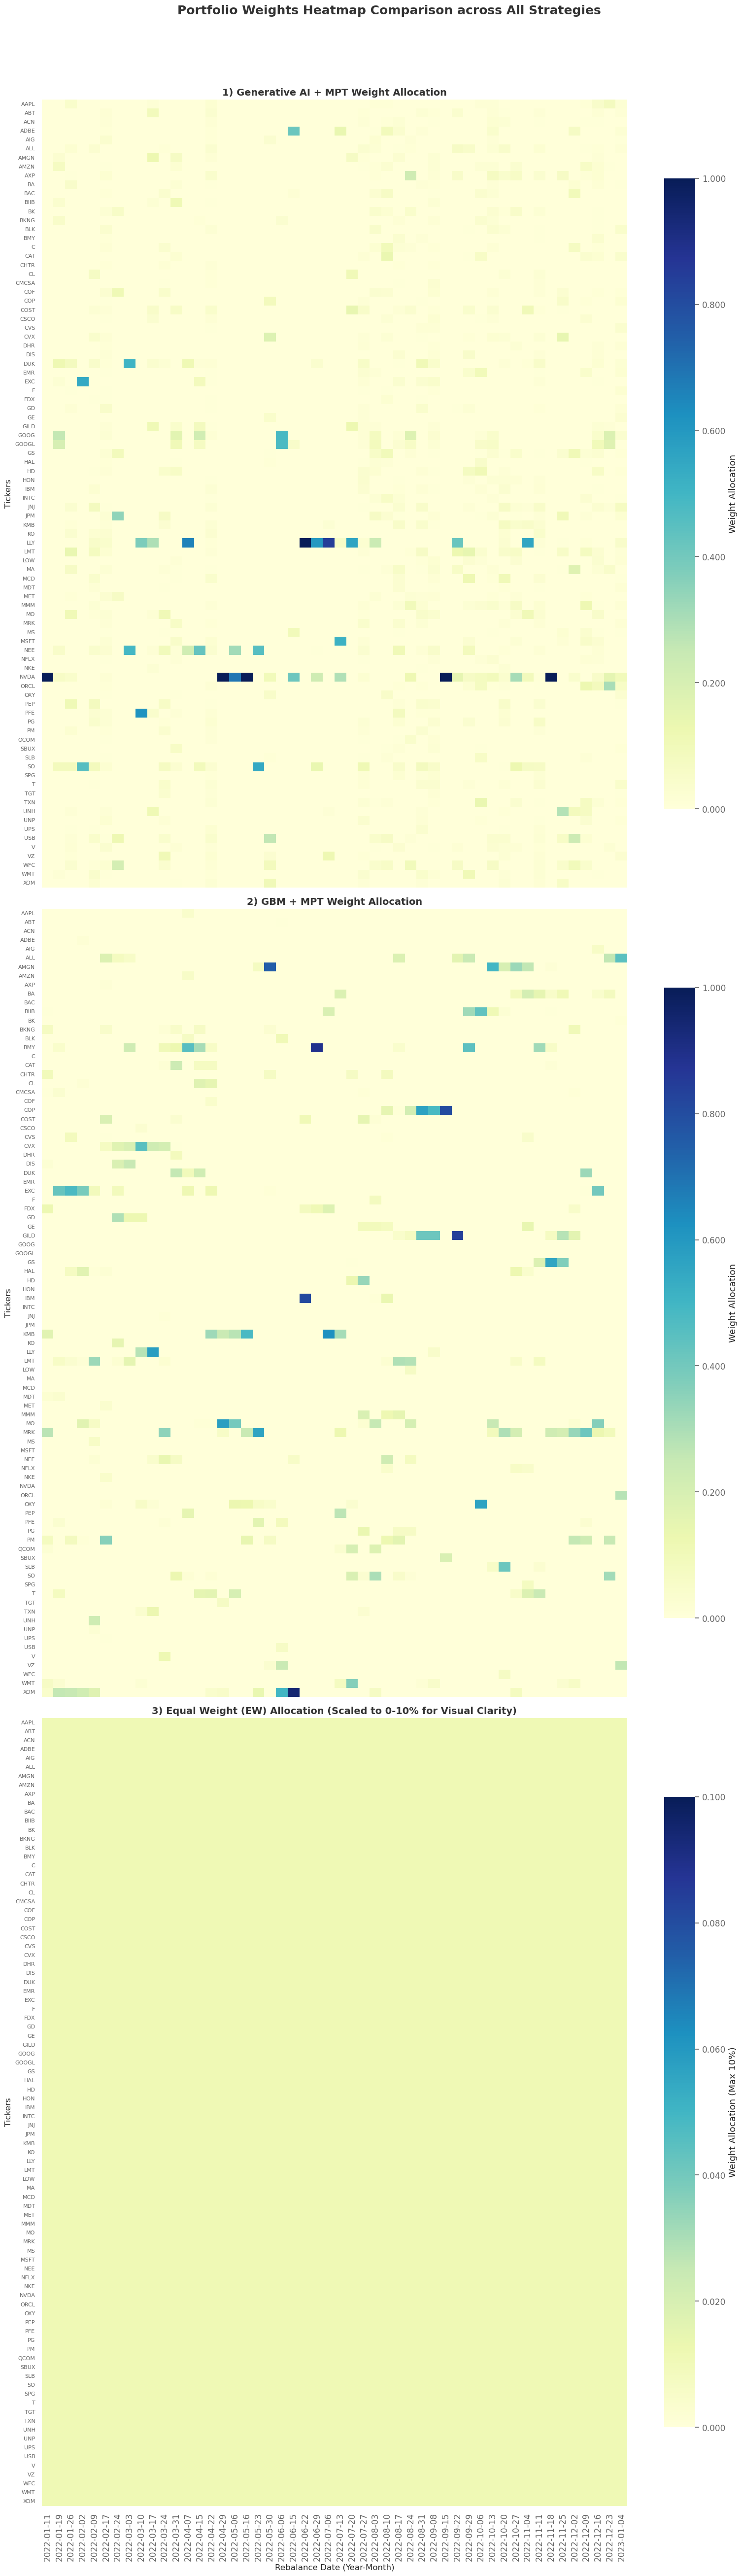

📸 บันทึกสำเร็จ: Report_SP100_Opt20_Rebalance5_SolverSCS/Portfolio-Equity_SP100_Opt20_Rebalance5_SolverSCS.png


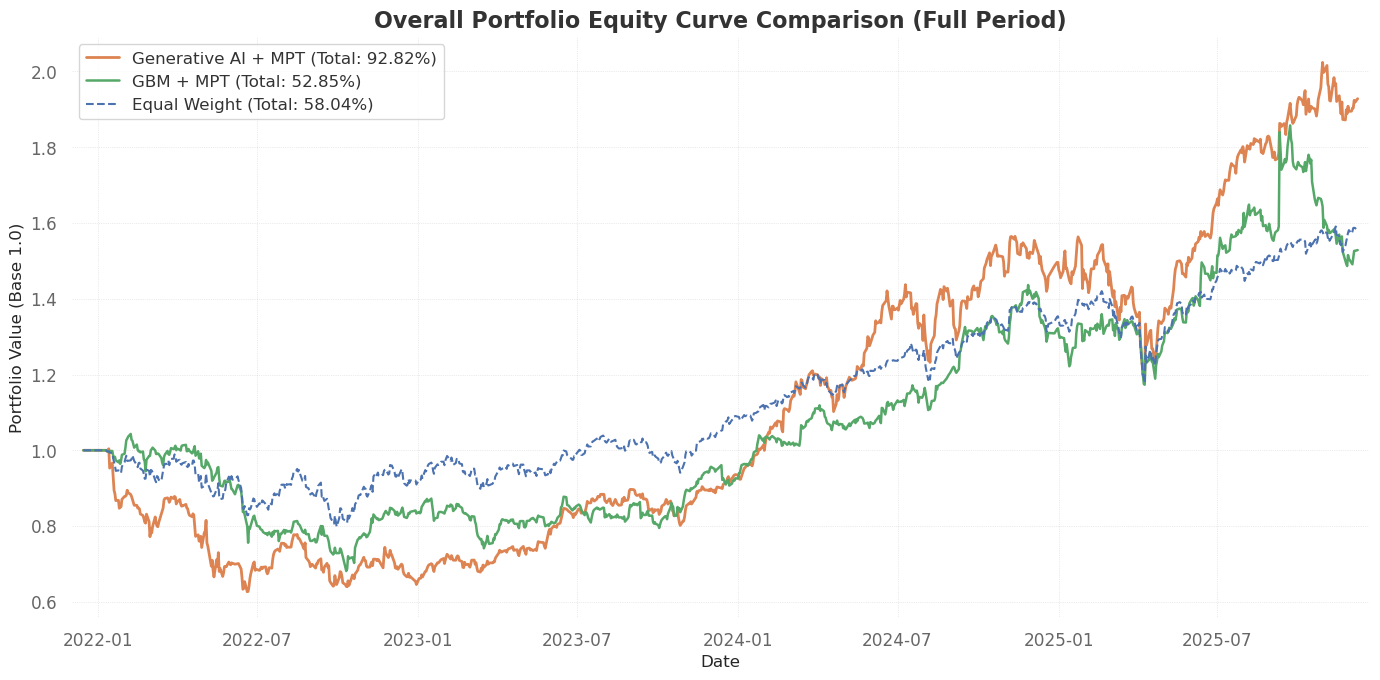

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. กำหนดชื่อไฟล์สำหรับเซฟรูป (อ้างอิงจากตัวแปรเดิม)
# ==========================================
weights_filename = f"Weights_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"
equity_filename = f"Portfolio-Equity_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"

# ==========================================
# 1. พล็อต Heatmap พร้อมปรับแถบสเกลสีให้แสดงทศนิยม 3 ตำแหน่ง
# ==========================================
# เตรียมข้อมูล Transpose และ Format Date
df_hm_model = df_weights.T
df_hm_model.columns = df_hm_model.columns.strftime('%Y-%m-%d') # 🔥 เปลี่ยนเป็น ปี-เดือน-วัน

df_hm_gbm = df_weights_gbm.T
df_hm_gbm.columns = df_hm_gbm.columns.strftime('%Y-%m-%d') # 🔥 เปลี่ยนเป็น ปี-เดือน-วัน

df_hm_ew = df_weights_ew.T
df_hm_ew.columns = df_hm_ew.columns.strftime('%Y-%m-%d') # 🔥 เปลี่ยนเป็น ปี-เดือน-วัน

# 🔥 1. ปรับความสูงกราฟให้ยืดหยุ่นตามจำนวน Asset (Asset ละประมาณ 0.5 นิ้ว)
num_assets = len(df_hm_model.index)
fig_height = max(18, num_assets * 0.6) # ถ้าหุ้นเยอะ กราฟจะยาวขึ้นตาม

fig, axes = plt.subplots(3, 1, figsize=(16, fig_height), sharex=True)

# 1. Generative AI + MPT
sns.heatmap(
    df_hm_model,
    cmap='YlGnBu',
    linewidths=0, # 🔥 2. ปรับเป็น 0 เพื่อไม่ให้เส้นตารางสีขาวกลืนสีข้อมูลเมื่อช่องมีขนาดเล็ก
    vmin=0,
    vmax=1.0,
    yticklabels=True,
    cbar_kws={'label': 'Weight Allocation', 'format': '%.3f', 'shrink': 0.8},
    ax=axes[0],
)
axes[0].set_title('1) Generative AI + MPT Weight Allocation', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tickers', fontsize=12)
axes[0].tick_params(axis='y', labelsize=8) # 🔥 3. ลดขนาด font แกน Y

# 2. GBM + MPT
sns.heatmap(
    df_hm_gbm,
    cmap='YlGnBu',
    linewidths=0, # 🔥 ปรับเป็น 0
    vmin=0,
    vmax=1.0,
    yticklabels=True,
    cbar_kws={'label': 'Weight Allocation', 'format': '%.3f', 'shrink': 0.8},
    ax=axes[1],
)
axes[1].set_title('2) GBM + MPT Weight Allocation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tickers', fontsize=12)
axes[1].tick_params(axis='y', labelsize=8) # 🔥 ลดขนาด font แกน Y

# 3. Equal Weight (EW)
sns.heatmap(
    df_hm_ew,
    cmap='YlGnBu',
    linewidths=0, # 🔥 ปรับเป็น 0
    vmin=0,
    vmax=0.10,
    yticklabels=True,
    cbar_kws={'label': 'Weight Allocation (Max 10%)', 'format': '%.3f', 'shrink': 0.8},
    ax=axes[2],
)
axes[2].set_title('3) Equal Weight (EW) Allocation (Scaled to 0-10% for Visual Clarity)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rebalance Date (Year-Month)', fontsize=12)
axes[2].set_ylabel('Tickers', fontsize=12)
axes[2].tick_params(axis='y', labelsize=8) # 🔥 ลดขนาด font แกน Y

# หมุนชื่อแกน Y ให้เป็นแนวนอนอ่านง่ายๆ และแกน X ให้เฉียงเพื่อประหยัดพื้นที่
for ax in axes:
    ax.tick_params(axis='y', rotation=0)
    ax.tick_params(axis='x', rotation=90) # ปรับแกน X เอียง 45 องศาไม่ให้ชนกัน

# ปรับตำแหน่ง Title รวมไม่ให้ชนกับกราฟแรก
plt.suptitle('Portfolio Weights Heatmap Comparison across All Strategies', fontsize=18, fontweight='bold', y=0.99)

# จัดระเบียบ layout เว้นขอบด้านบนไว้เผื่อ Title
plt.tight_layout(rect=[0, 0, 1, 0.97])

# 🔥 บันทึกรูปลง Directory ที่เตรียมไว้
weights_path = save_dir / weights_filename
plt.savefig(weights_path, bbox_inches='tight', dpi=300)
print(f"📸 บันทึกสำเร็จ: {weights_path}")

plt.show()

# ==========================================
# 2. พล็อตกราฟ Overall Portfolio Equity Curve ทั้ง 3 กลยุทธ์
# ==========================================
# ดึงมูลค่าพอร์ตและปรับฐานให้เริ่มต้นที่ 1.0
eq_model = portfolio.value() / portfolio.value().iloc[0]
eq_gbm = portfolio_gbm.value() / portfolio_gbm.value().iloc[0]
eq_ew = portfolio_ew.value() / portfolio_ew.value().iloc[0]

# คำนวณผลตอบแทนรวม (Total Return %)
tot_ret_model = (eq_model.iloc[-1] - 1) * 100
tot_ret_gbm = (eq_gbm.iloc[-1] - 1) * 100
tot_ret_ew = (eq_ew.iloc[-1] - 1) * 100

plt.figure(figsize=(14, 7))

# พล็อตเส้นกราฟทั้ง 3 โมเดล
plt.plot(
    eq_model.index,
    eq_model,
    label=f'Generative AI + MPT (Total: {tot_ret_model:.2f}%)',
    color='#dd8452',
    linewidth=2.0,
)
plt.plot(
    eq_gbm.index,
    eq_gbm,
    label=f'GBM + MPT (Total: {tot_ret_gbm:.2f}%)',
    color='#55a868',
    linewidth=1.8,
)
plt.plot(
    eq_ew.index,
    eq_ew,
    label=f'Equal Weight (Total: {tot_ret_ew:.2f}%)',
    color='#4c72b0',
    linewidth=1.5,
    linestyle='--',
)

plt.title(
    'Overall Portfolio Equity Curve Comparison (Full Period)',
    fontweight='bold',
    fontsize=16,
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.grid(True, alpha=0.3, color='gray', linestyle=':')
plt.margins(x=0.01)
plt.tight_layout()

# 🔥 บันทึกรูปลง Directory ที่เตรียมไว้
equity_path = save_dir / equity_filename
plt.savefig(equity_path, bbox_inches='tight', dpi=300)
print(f"📸 บันทึกสำเร็จ: {equity_path}")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier
import vectorbt as vbt
import quantstats as qs
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

def run_portfolio_pipeline(
    # --- 1. ข้อมูลตั้งต้นที่ต้องโยนเข้ามา ---
    all_log_ret_gen, gt_prices, datetime_index, tickers, T, N, W,

    # --- 2. Parameter ที่ตั้งค่า Default ตามที่ต้องการ ---
    OPT_WINDOW = 20,
    REBALANCE_FREQ = 10,
    RF_RATE = 0.02,
    TRADING_FEE = 0.0025,
    TRADING_DAYS = 252,
    SOLVER = "SCS",
    ASSET_NAME = "SP100"
):
    print(f"\n{'='*60}")
    print(f"🚀 เริ่มรัน Pipeline: {ASSET_NAME} | Opt: {OPT_WINDOW} | Reb: {REBALANCE_FREQ} | Solver: {SOLVER}")
    print(f"{'='*60}\n")

    # เช็ค Logic
    if OPT_WINDOW > W:
        raise ValueError(f"🚨 ข้อผิดพลาด: OPT_WINDOW ({OPT_WINDOW}) ใหญ่กว่าขนาด Window W ({W})")

    # ==========================================
    # 0. ตั้งค่าชื่อไฟล์และสร้าง Folder
    # ==========================================
    SOLVER_NAME = SOLVER
    folder_name = f"Report_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}"
    save_dir = Path(folder_name)
    save_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 โฟลเดอร์สำหรับบันทึกข้อมูล: {save_dir}")

    weights_filename = f"Weights_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"
    equity_filename = f"Portfolio-Equity_{ASSET_NAME}_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.png"

    # ==========================================
    # 1. การเตรียมข้อมูล & วันที่ Rebalance
    # ==========================================
    close_log_ret_gen = all_log_ret_gen[:, :, :, :, 0]
    df_prices_full = pd.DataFrame(gt_prices, index=datetime_index, columns=tickers)
    df_prices_full = df_prices_full[~df_prices_full.index.duplicated(keep='last')]

    # วันที่ Rebalance
    rebalance_dates = df_prices_full.index[OPT_WINDOW - 1 :: REBALANCE_FREQ]
    if len(rebalance_dates) > T:
        rebalance_dates = rebalance_dates[:T]

    # ==========================================
    # 2. Optimization: Generative AI + MPT
    # ==========================================
    print(f"⚙️ 1/3 กำลังรัน Optimization (Generative AI + MPT)...")
    count_max_sharpe, count_min_volatility = 0, 0
    weights_list = []

    for t in range(T):
        mu_paths, cov_paths = [], []
        for n in range(N):
            path_log_returns = close_log_ret_gen[t, n, -OPT_WINDOW:, :]
            path_simple_returns = np.exp(path_log_returns) - 1

            mu_m = np.mean(path_simple_returns, axis=0) * TRADING_DAYS
            cov_m = np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS
            mu_paths.append(mu_m)
            cov_paths.append(cov_m)

        mu_ensemble = np.mean(mu_paths, axis=0)
        cov_ensemble = np.mean(cov_paths, axis=0)

        mu_series = pd.Series(mu_ensemble, index=tickers)
        cov_df = pd.DataFrame(cov_ensemble, index=tickers, columns=tickers)
        cov_df = cov_df + (np.eye(len(cov_df)) * 1e-4) # ป้องกัน matrix error

        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1), solver=SOLVER)
        try:
            raw_weights = ef.max_sharpe(risk_free_rate=RF_RATE)
            count_max_sharpe += 1
        except ValueError:
            ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1))
            raw_weights = ef.min_volatility()
            count_min_volatility += 1

        cleaned_weights = ef.clean_weights()
        weights_list.append(np.array([cleaned_weights[t] for t in tickers]))

    df_weights = pd.DataFrame(weights_list, index=rebalance_dates, columns=tickers)
    df_weights_full = df_weights.reindex(df_prices_full.index)

    portfolio = vbt.Portfolio.from_orders(
        close=df_prices_full, size=df_weights_full, size_type='targetpercent',
        cash_sharing=True, call_seq='auto', fees=TRADING_FEE, freq='1D'
    )

    # ==========================================
    # 3. Optimization: Equal Weight (EW)
    # ==========================================
    print(f"⚙️ 2/3 กำลังรัน Baseline (Equal Weight)...")
    df_weights_ew = pd.DataFrame(1.0 / len(tickers), index=rebalance_dates, columns=tickers)
    df_weights_ew_full = df_weights_ew.reindex(df_prices_full.index)

    portfolio_ew = vbt.Portfolio.from_orders(
        close=df_prices_full, size=df_weights_ew_full, size_type='targetpercent',
        cash_sharing=True, call_seq='auto', fees=TRADING_FEE, freq='1D'
    )

    # ==========================================
    # 4. Optimization: GBM + MPT
    # ==========================================
    print("⚙️ 3/3 กำลังรัน Baseline (GBM + MPT)...")
    gbm_weights_list = []

    for idx, reb_date in enumerate(rebalance_dates):
        loc = df_prices_full.index.get_loc(reb_date)
        hist_prices = df_prices_full.iloc[loc - OPT_WINDOW + 1 : loc + 1]
        hist_log_returns = np.log(hist_prices / hist_prices.shift(1)).dropna()

        dt = 1 / TRADING_DAYS
        mu_daily = hist_log_returns.mean().values
        cov_daily = hist_log_returns.cov().values
        num_assets = len(tickers)

        try:
            L = np.linalg.cholesky(cov_daily)
        except np.linalg.LinAlgError:
            cov_daily += np.eye(num_assets) * 1e-6
            L = np.linalg.cholesky(cov_daily)

        simulated_paths_log_ret = []
        for n in range(N):
            Z = np.random.normal(size=(W, num_assets))
            simulated_paths_log_ret.append(mu_daily + Z @ L.T)
        simulated_paths_log_ret = np.array(simulated_paths_log_ret)

        mu_paths, cov_paths = [], []
        for n in range(N):
            path_simple_returns = np.exp(simulated_paths_log_ret[n, -OPT_WINDOW:, :]) - 1
            mu_paths.append(np.mean(path_simple_returns, axis=0) * TRADING_DAYS)
            cov_paths.append(np.cov(path_simple_returns, rowvar=False) * TRADING_DAYS)

        mu_series = pd.Series(np.mean(mu_paths, axis=0), index=tickers)
        cov_df = pd.DataFrame(np.mean(cov_paths, axis=0), index=tickers, columns=tickers)

        ef = EfficientFrontier(mu_series, cov_df, weight_bounds=(0, 1), solver=SOLVER)
        try:
            raw_weights = ef.max_sharpe(risk_free_rate=RF_RATE)
        except ValueError:
            raw_weights = ef.min_volatility()

        cleaned_weights = ef.clean_weights()
        gbm_weights_list.append(np.array([cleaned_weights[t] for t in tickers]))

    df_weights_gbm = pd.DataFrame(gbm_weights_list, index=rebalance_dates, columns=tickers)
    df_weights_gbm_full = df_weights_gbm.reindex(df_prices_full.index)

    portfolio_gbm = vbt.Portfolio.from_orders(
        close=df_prices_full, size=df_weights_gbm_full, size_type='targetpercent',
        cash_sharing=True, call_seq='auto', fees=TRADING_FEE, freq='1D'
    )

    # ==========================================
    # 5. สร้าง QuantStats Report
    # ==========================================
    print(f"\n📊 กำลังสร้างและบันทึก QuantStats Reports...")
    ret_genai = portfolio.returns()
    ret_ew = portfolio_ew.returns()
    ret_gbm = portfolio_gbm.returns()

    pairs = [
        (ret_genai, ret_ew, f"Report_{ASSET_NAME}_GenAI_vs_EW_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html", f"GenAI vs EW"),
        (ret_genai, ret_gbm, f"Report_{ASSET_NAME}_GenAI_vs_GBM_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html", f"GenAI vs GBM"),
        (ret_gbm, ret_ew, f"Report_{ASSET_NAME}_GBM_vs_EW_Opt{OPT_WINDOW}_Rebalance{REBALANCE_FREQ}_Solver{SOLVER_NAME}.html", f"GBM vs EW")
    ]

    for port_ret, bench_ret, fname, title in pairs:
        fpath = str(save_dir / fname)
        qs.reports.html(returns=port_ret, benchmark=bench_ret, rf=RF_RATE,
                        title=f"{title} (Opt: {OPT_WINDOW}, Reb: {REBALANCE_FREQ})", output=fpath)
        print(f" 💾 บันทึกสำเร็จ: {fpath}")

    # ==========================================
    # 6. พล็อตกราฟ (Pie Chart, Heatmap, Equity Curve)
    # ==========================================
    print("\n🎨 กำลังวาดกราฟสรุปผล...")

    # 6.1 Pie Chart
    plt.figure(figsize=(8, 8))
    total_opts = count_max_sharpe + count_min_volatility
    plt.pie([count_max_sharpe, count_min_volatility], explode=(0.05, 0), labels=['Max Sharpe', 'Minimum Variance'],
            colors=['#4CAF50', '#FFC107'], autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
    plt.title(f'Portfolio Optimization Objective Breakdown\n(Total: {total_opts} Rebalances)', fontsize=14, weight='bold', pad=30)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(save_dir / f"Objective_PieChart_{ASSET_NAME}_Opt{OPT_WINDOW}.png", bbox_inches='tight', dpi=300)
    plt.close() # วาดเสร็จแล้วเคลียร์ออก ไม่ต้องโชว์รกหน้าจอตอนรันฟังก์ชัน

    # 6.2 Heatmap
    fig_height = max(18, len(tickers) * 0.6)
    fig, axes = plt.subplots(3, 1, figsize=(16, fig_height), sharex=True)

    dfs = [df_weights.T, df_weights_gbm.T, df_weights_ew.T]
    titles = ['1) Generative AI + MPT', '2) GBM + MPT', '3) Equal Weight (EW)']
    vmaxs = [1.0, 1.0, 0.10]

    for i, (df, ax) in enumerate(zip(dfs, axes)):
        df.columns = df.columns.strftime('%Y-%m-%d')
        sns.heatmap(df, cmap='YlGnBu', linewidths=0, vmin=0, vmax=vmaxs[i],
                    cbar_kws={'label': 'Weight Allocation', 'format': '%.3f', 'shrink': 0.8}, ax=ax)
        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8, rotation=0)
        if i == 2: ax.set_xlabel('Rebalance Date (Year-Month)', fontsize=12)
        ax.tick_params(axis='x', rotation=90)

    plt.suptitle('Portfolio Weights Heatmap Comparison', fontsize=18, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(save_dir / weights_filename, bbox_inches='tight', dpi=300)
    plt.close()

    # 6.3 Equity Curve
    eq_model, eq_gbm, eq_ew = portfolio.value() / portfolio.value().iloc[0], portfolio_gbm.value() / portfolio_gbm.value().iloc[0], portfolio_ew.value() / portfolio_ew.value().iloc[0]
    plt.figure(figsize=(14, 7))
    plt.plot(eq_model.index, eq_model, label=f'GenAI + MPT (Total: {(eq_model.iloc[-1] - 1)*100:.2f}%)', color='#dd8452', lw=2)
    plt.plot(eq_gbm.index, eq_gbm, label=f'GBM + MPT (Total: {(eq_gbm.iloc[-1] - 1)*100:.2f}%)', color='#55a868', lw=1.8)
    plt.plot(eq_ew.index, eq_ew, label=f'Equal Weight (Total: {(eq_ew.iloc[-1] - 1)*100:.2f}%)', color='#4c72b0', lw=1.5, ls='--')
    plt.title('Overall Portfolio Equity Curve Comparison', fontweight='bold', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Portfolio Value (Base 1.0)', fontsize=12)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3, ls=':')
    plt.margins(x=0.01)
    plt.tight_layout()
    plt.savefig(save_dir / equity_filename, bbox_inches='tight', dpi=300)
    plt.close()

    print(f"\n🎉 รันเสร็จสิ้น! ข้อมูลทั้งหมดถูกบันทึกไว้ที่: {save_dir}")

    # รีเทิร์นค่ากลับไปเผื่ออยากเอาไปดึงค่าต่อข้างนอก
    return portfolio, portfolio_gbm, portfolio_ew

In [103]:
rebalance_freqs = [1, 5, 10, 20]
OPT_WINDOW = 5
for rebalance_freq in rebalance_freqs:
    port_genai, port_gbm, port_ew = run_portfolio_pipeline(
        all_log_ret_gen = all_log_ret_gen,
        gt_prices = gt_prices,
        datetime_index = datetime_index,
        tickers = tickers,
        T = T,
        N = N,
        W = W,
        OPT_WINDOW=OPT_WINDOW,
        REBALANCE_FREQ=rebalance_freq,
        ASSET_NAME="SP100"
    )


🚀 เริ่มรัน Pipeline: SP100 | Opt: 5 | Reb: 1 | Solver: SCS

📁 โฟลเดอร์สำหรับบันทึกข้อมูล: Report_SP100_Opt5_Rebalance1_SolverSCS
⚙️ 1/3 กำลังรัน Optimization (Generative AI + MPT)...
⚙️ 2/3 กำลังรัน Baseline (Equal Weight)...
⚙️ 3/3 กำลังรัน Baseline (GBM + MPT)...

📊 กำลังสร้างและบันทึก QuantStats Reports...
2026-07-25 19:26:49,841 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,843 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,886 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,887 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,944 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,945 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-07-25 19:26:49,946 - matplotlib.font_manager - WARNING - findfont